In [ ]:
!nvidia-smi

Thu Jul 30 14:56:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
%pip install -q \
    numpy==1.26.4 \
    albumentations==2.0.0 \
    imgaug==0.4.0 \
    omegaconf==2.3.0 \
    timm==1.0.13 \
    transformers==4.48.0 \
    tensorboard==2.18.0 \
    scikit-image==0.24.0 \
    shapely==2.0.6 \
    nltk==3.9.1
%pip install -q numpy==1.26.4 imgaug==0.4.0

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
%cd /content
!rm -rf /content/Mammo-FM
!git clone -b poc-colab https://github.com/bakuann/Mammo-FM.git

/content
Cloning into 'Mammo-FM'...
remote: Enumerating objects: 627, done.
remote: Counting objects: 100% (627/627), done.
remote: Compressing objects: 100% (473/473), done.
remote: Total 627 (delta 184), reused 581 (delta 142), pack-reused 0 (from 0)
Receiving objects: 100% (627/627), 2.94 MiB | 8.24 MiB/s, done.
Resolving deltas: 100% (184/184), done.


In [2]:
!git status --short

fatal: not a git repository (or any of the parent directories): .git


In [7]:
!mkdir -p /content/Mammo-FM/weights

!cp "/content/drive/MyDrive/Mammo-FM/weights/Mammo-FM_BatmanlabTrained_CLIP.tar" \
    "/content/Mammo-FM/weights/"

In [3]:
!ls -lh /content/Mammo-FM/weights

total 2.0G
-rw------- 1 root root 2.0G Jul 30 15:15 Mammo-FM_BatmanlabTrained_CLIP.tar


In [4]:
%cd /content/Mammo-FM

import os
import torch

CKPT_PATH = (
    "/content/Mammo-FM/weights/"
    "Mammo-FM_BatmanlabTrained_CLIP.tar"
)

assert torch.cuda.is_available(), "Colab chưa bật GPU"
assert os.path.isfile(CKPT_PATH), f"Không tìm thấy: {CKPT_PATH}"

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("Checkpoint size:", round(os.path.getsize(CKPT_PATH) / 1024**3, 2), "GB")

/content/Mammo-FM
PyTorch: 2.11.0+cu128
GPU: Tesla T4
Checkpoint size: 2.0 GB


In [5]:
checkpoint = torch.load(
    CKPT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("Checkpoint keys:", checkpoint.keys())
print("\nImage encoder config:")
print(checkpoint["config"]["model"]["image_encoder"])

Checkpoint keys: dict_keys(['model', 'optimizer', 'scheduler', 'config', 'epoch', 'train_loss'])

Image encoder config:
{'source': 'cnn', 'name': 'tf_efficientnet_b5_ns-detect', 'pretrained': True, 'model_type': 'cnn'}


In [6]:
import sys
from types import SimpleNamespace

sys.path.insert(0, "/content/Mammo-FM/src/codebase")

from Classifiers.models.breast_clip_classifier import BreastClipClassifier

args = SimpleNamespace(
    arch="breast_clip_det_b5_period_n_lp"
)

model = BreastClipClassifier(
    args=args,
    ckpt=checkpoint,
    n_class=1,
)

model = model.cuda().eval()

print("Model loaded successfully")
print("Image encoder:", model.get_image_encoder_type())

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.0'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Successfully imported and registered ModernBERT modules


[nltk_data] Downloading package punkt to /content/Mammo-
[nltk_data]     FM/src/codebase/breastclip/../../nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


{'source': 'cnn', 'name': 'tf_efficientnet_b5_ns-detect', 'pretrained': True, 'model_type': 'cnn'}
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b5-b6417697.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b5-b6417697.pth


100%|██████████| 117M/117M [00:02<00:00, 43.5MB/s]


<All keys matched successfully>
Loaded pretrained weights for efficientnet-b5
freezing image encoder to not be trained
Model loaded successfully
Image encoder: cnn


In [7]:
import gc
import torch

del checkpoint
gc.collect()
torch.cuda.empty_cache()

def test_resolution(height, width):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    try:
        dummy = torch.zeros(
            1, 3, height, width,
            device="cuda",
            dtype=torch.float32,
        )

        with torch.inference_mode():
            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
            ):
                output = model(dummy)

        peak_vram = torch.cuda.max_memory_allocated() / 1024**3

        print(
            f"{width}x{height}: OK | "
            f"output={tuple(output.shape)} | "
            f"peak VRAM={peak_vram:.2f} GB"
        )

        del dummy, output

    except torch.cuda.OutOfMemoryError:
        print(f"{width}x{height}: CUDA OOM")
        torch.cuda.empty_cache()


test_resolution(512, 768)
test_resolution(640, 1024)
test_resolution(912, 1520)

768x512: OK | output=(1, 1) | peak VRAM=0.20 GB
1024x640: OK | output=(1, 1) | peak VRAM=0.27 GB
1520x912: OK | output=(1, 1) | peak VRAM=0.43 GB


In [8]:
from pathlib import Path
import shutil

DATA_ROOT = Path("/content/data/vindr")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

SOURCE_CSV = Path(
    "/content/Mammo-FM/src/codebase/data_csv/"
    "vindr_detection_v1_folds.csv"
)

TARGET_CSV = DATA_ROOT / "vindr_detection_v1_folds.csv"

shutil.copy2(SOURCE_CSV, TARGET_CSV)

print("Metadata:", TARGET_CSV)
print("Exists:", TARGET_CSV.exists())

Metadata: /content/data/vindr/vindr_detection_v1_folds.csv
Exists: True


In [9]:
import pandas as pd

df = pd.read_csv(TARGET_CSV)

print("Số dòng annotation:", len(df))
print("Số ảnh duy nhất:", df["image_id"].nunique())
print("Số examination/patient:", df["patient_id"].nunique())

print("\nPhân bố split:")
print(df.groupby("split")["image_id"].nunique())

print("\nCác cột:")
print(df.columns.tolist())

Số dòng annotation: 20486
Số ảnh duy nhất: 20000
Số examination/patient: 5000

Phân bố split:
split
test         4000
training    16000
Name: image_id, dtype: int64

Các cột:
['patient_id', 'series_id', 'image_id', 'laterality', 'view', 'height', 'width', 'breast_birads', 'breast_density', 'finding_categories', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax', 'split', 'resized_xmin', 'resized_ymin', 'resized_xmax', 'resized_ymax', 'fold', 'Architectural_Distortion', 'Asymmetry', 'Focal_Asymmetry', 'Global_Asymmetry', 'Mass', 'Nipple_Retraction', 'No_Finding', 'Skin_Retraction', 'Skin_Thickening', 'Suspicious_Calcification', 'Suspicious_Lymph_Node', 'density']


/tmp/ipykernel_8266/1486951463.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(TARGET_CSV)


In [10]:
from pathlib import Path

DRIVE_TAR = Path(
    "/content/drive/MyDrive/Mammo-FM/data/"
    "vindr_images_png.tar"
)

assert DRIVE_TAR.exists(), f"Không tìm thấy {DRIVE_TAR}"

print("Archive size:", round(DRIVE_TAR.stat().st_size / 1024**3, 2), "GB")

Archive size: 7.73 GB


In [11]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   52G   61G  46% /


In [12]:
from pathlib import Path
import subprocess

DATA_ROOT = Path("/content/data/vindr")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

subprocess.run(
    [
        "tar",
        "-xf",
        str(DRIVE_TAR),
        "-C",
        str(DATA_ROOT),
    ],
    check=True,
)

print("Extraction completed")

Extraction completed


In [13]:
#6. Copy metadata từ repo
import shutil

SOURCE_CSV = Path(
    "/content/Mammo-FM/src/codebase/data_csv/"
    "vindr_detection_v1_folds.csv"
)

TARGET_CSV = DATA_ROOT / "vindr_detection_v1_folds.csv"

shutil.copy2(SOURCE_CSV, TARGET_CSV)

print(TARGET_CSV)

/content/data/vindr/vindr_detection_v1_folds.csv


In [14]:
#7. Kiểm tra ảnh có khớp metadata không
import pandas as pd

df = pd.read_csv(TARGET_CSV)

unique_images = (
    df[["patient_id", "image_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

missing = []

for row in unique_images.itertuples(index=False):
    image_path = (
        DATA_ROOT
        / "images_png"
        / str(row.patient_id)
        / str(row.image_id)
    )

    if not image_path.exists():
        missing.append(str(image_path))

print("Số ảnh metadata:", len(unique_images))
print("Số ảnh thiếu:", len(missing))

if missing:
    print("Ví dụ ảnh thiếu:")
    print(*missing[:10], sep="\n")

/tmp/ipykernel_8266/2988123068.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(TARGET_CSV)


Số ảnh metadata: 20000
Số ảnh thiếu: 0


In [15]:
#Cell 1 — tạo metadata một dòng cho mỗi ảnh
from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/content/data/vindr")
CSV_PATH = DATA_ROOT / "vindr_detection_v1_folds.csv"

df = pd.read_csv(CSV_PATH)

# Lấy số BI-RADS từ chuỗi như "BI-RADS 4"
df["birads_num"] = (
    df["breast_birads"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

df = df.dropna(subset=["birads_num"]).copy()
df["birads_num"] = df["birads_num"].astype(int)

# Working definition của nhãn triage
df["triage"] = (df["birads_num"] >= 3).astype(int)

# Kiểm tra các dòng annotation của cùng một ảnh có metadata nhất quán
consistency = (
    df.groupby(["patient_id", "image_id"])
    [["laterality", "view", "split", "birads_num", "triage"]]
    .nunique()
)

assert consistency.max().max() == 1, \
    "Có một ảnh mang nhiều metadata/nhãn không nhất quán"

# Một ảnh có thể có nhiều annotation; triage chỉ cần một dòng/ảnh
image_df = (
    df.sort_values(["patient_id", "image_id"])
    .drop_duplicates(["patient_id", "image_id"])
    .reset_index(drop=True)
)

print("Dòng annotation ban đầu:", len(df))
print("Số ảnh sau deduplicate:", len(image_df))
print("\nSplit:")
print(image_df["split"].value_counts())

print("\nTriage:")
print(image_df["triage"].value_counts())

Dòng annotation ban đầu: 20486
Số ảnh sau deduplicate: 20000

Split:
split
training    16000
test         4000
Name: count, dtype: int64

Triage:
triage
0    18082
1     1918
Name: count, dtype: int64


/tmp/ipykernel_8266/40052048.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


In [16]:
#Cell 2 — lưu metadata triage
TRIAGE_CSV = DATA_ROOT / "vindr_triage_image_level.csv"
image_df.to_csv(TRIAGE_CSV, index=False)

DRIVE_SPLIT_DIR = Path(
    "/content/drive/MyDrive/Mammo-FM/data/splits"
)
DRIVE_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

image_df.to_csv(
    DRIVE_SPLIT_DIR / "vindr_triage_image_level.csv",
    index=False,
)

print("Local:", TRIAGE_CSV)
print("Drive:", DRIVE_SPLIT_DIR / "vindr_triage_image_level.csv")

Local: /content/data/vindr/vindr_triage_image_level.csv
Drive: /content/drive/MyDrive/Mammo-FM/data/splits/vindr_triage_image_level.csv


In [17]:
#Cell 3 — kiểm tra mỗi examination có đủ 4 view
train_df = image_df[
    image_df["split"] == "training"
].copy()

exam_summary = (
    train_df.groupby("patient_id")
    .agg(
        n_images=("image_id", "nunique"),
        n_views=("view", "nunique"),
        n_lateralities=("laterality", "nunique"),
        exam_triage=("triage", "max"),
    )
    .reset_index()
)

print("Phân bố số ảnh/exam:")
print(exam_summary["n_images"].value_counts().sort_index())

print("\nExam không đủ 4 ảnh:")
print((exam_summary["n_images"] != 4).sum())

print("\nNhãn exam-level:")
print(exam_summary["exam_triage"].value_counts())

Phân bố số ảnh/exam:
n_images
4    4000
Name: count, dtype: int64

Exam không đủ 4 ảnh:
0

Nhãn exam-level:
exam_triage
0    3270
1     730
Name: count, dtype: int64


In [18]:
#Cell 4 — chọn 32 exam cân bằng
SEED = 42
N_PER_CLASS = 16

eligible = exam_summary[
    (exam_summary["n_images"] == 4)
    & (exam_summary["n_views"] == 2)
    & (exam_summary["n_lateralities"] == 2)
].copy()

positive_ids = (
    eligible[eligible["exam_triage"] == 1]
    .sample(n=N_PER_CLASS, random_state=SEED)
    ["patient_id"]
)

negative_ids = (
    eligible[eligible["exam_triage"] == 0]
    .sample(n=N_PER_CLASS, random_state=SEED)
    ["patient_id"]
)

selected_ids = set(positive_ids) | set(negative_ids)

overfit_df = (
    train_df[train_df["patient_id"].isin(selected_ids)]
    .sort_values(["patient_id", "laterality", "view"])
    .reset_index(drop=True)
)

OVERFIT_CSV = DATA_ROOT / "overfit_32_exams.csv"
overfit_df.to_csv(OVERFIT_CSV, index=False)

overfit_df.to_csv(
    DRIVE_SPLIT_DIR / "overfit_32_exams.csv",
    index=False,
)

print("Số exam:", overfit_df["patient_id"].nunique())
print("Số ảnh:", overfit_df["image_id"].nunique())
print("\nNhãn image-level:")
print(overfit_df["triage"].value_counts())

Số exam: 32
Số ảnh: 128

Nhãn image-level:
triage
0    96
1    32
Name: count, dtype: int64


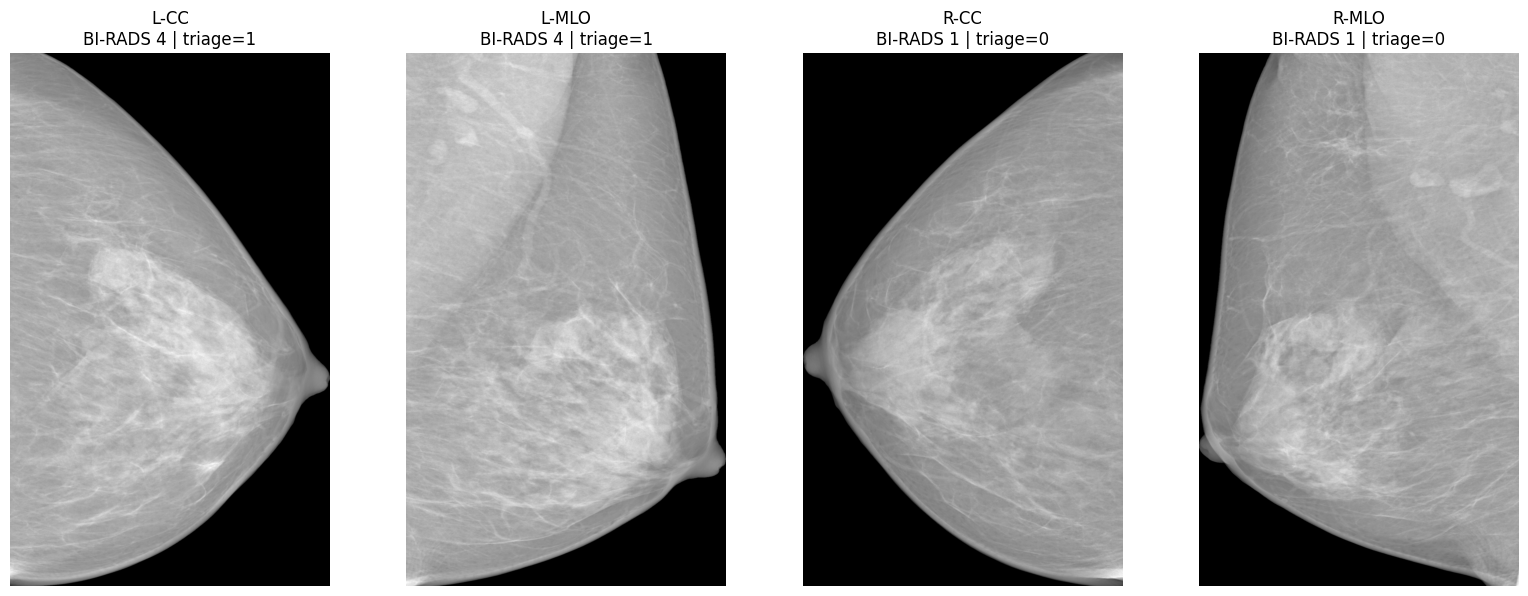

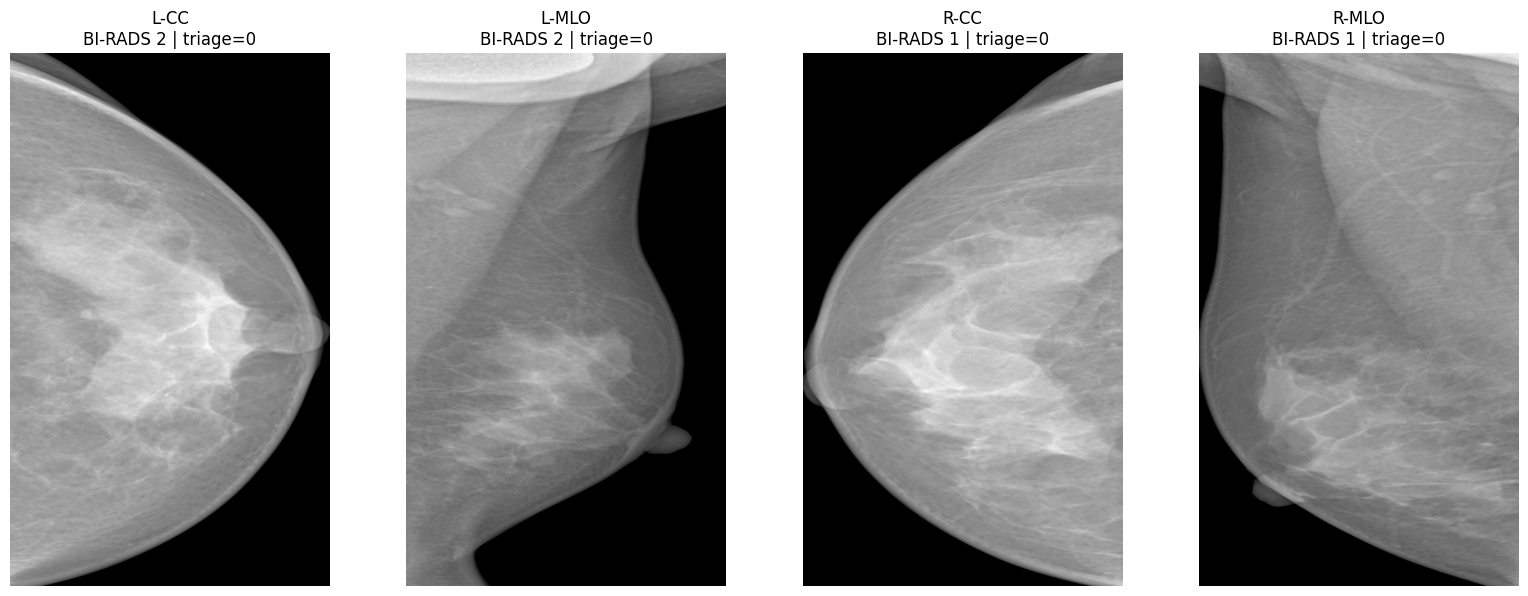

In [19]:
#Cell 5 — hiển thị một exam để kiểm tra
import matplotlib.pyplot as plt
from PIL import Image

def show_exam(patient_id):
    rows = overfit_df[
        overfit_df["patient_id"] == patient_id
    ].copy()

    rows["order"] = (
        rows["laterality"].map({"L": 0, "R": 2})
        + rows["view"].map({"CC": 0, "MLO": 1})
    )
    rows = rows.sort_values("order")

    fig, axes = plt.subplots(1, 4, figsize=(16, 6))

    for ax, row in zip(axes, rows.itertuples(index=False)):
        path = (
            DATA_ROOT
            / "images_png"
            / str(row.patient_id)
            / str(row.image_id)
        )

        image = Image.open(path)

        ax.imshow(image, cmap="gray")
        ax.set_title(
            f"{row.laterality}-{row.view}\n"
            f"BI-RADS {row.birads_num} | triage={row.triage}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_exam(positive_ids.iloc[0])
show_exam(negative_ids.iloc[0])

In [20]:
import numpy as np

print(np.__version__)

1.26.4


In [21]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/content/data/vindr")
OVERFIT_CSV = DATA_ROOT / "overfit_32_exams.csv"

overfit_df = pd.read_csv(OVERFIT_CSV)

print("Images:", overfit_df["image_id"].nunique())
print("Exams:", overfit_df["patient_id"].nunique())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images: 128
Exams: 32


In [22]:
#Cell 6 — kiểm tra DataLoader
import sys
from types import SimpleNamespace

import torch
from torch.utils.data import DataLoader
from albumentations import Compose, Resize

sys.path.insert(0, "/content/Mammo-FM/src/codebase")

from Datasets.dataset_concepts import (
    MammoDataset,
    collator_mammo_dataset_w_concepts,
)

args = SimpleNamespace(
    data_dir=DATA_ROOT,
    img_dir="images_png",
    dataset="vindr",
    image_encoder_type="cnn",
    label="triage",
    mean=0.3089279,
    std=0.25053555408335154,
)

transform = Compose([
    Resize(height=512, width=768),
])

dataset = MammoDataset(
    args=args,
    df=overfit_df,
    transform=transform,
)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collator_mammo_dataset_w_concepts,
)

batch = next(iter(loader))

# Repo trả về [B, 1, H, W, C]; chuyển thành [B, C, H, W]
images = (
    batch["x"]
    .squeeze(1)
    .permute(0, 3, 1, 2)
    .contiguous()
)

labels = batch["y"]

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Label values:", labels.tolist())
print("Range:", images.min().item(), images.max().item())
print("Example paths:")
print(*batch["img_path"][:4], sep="\n")

transforms:Compose([
  Resize(p=1.0, height=512, width=768, interpolation=1, mask_interpolation=0),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)
Images: torch.Size([4, 3, 512, 768])
Labels: torch.Size([4])
Label values: [1.0, 1.0, 0.0, 0.0]
Range: -1.2330701351165771 2.7583794593811035
Example paths:
/content/data/vindr/images_png/1b43d2adcf3f300c550d3030b16c861f/4d59a1f3bc1183b998c28b18f531fb9d.png
/content/data/vindr/images_png/4b31fd58a3f25c683ffd9eb96c43245a/cb3992b10ef27de6c2b735d792c58be0.png
/content/data/vindr/images_png/996f1876ba61a22dbe494eaaddab5f68/7b51fd446532c88aa2945ca39b3156af.png
/content/data/vindr/images_png/4f113acfcdc2c90fc2125dfc434cc03b/6956e17a4f9cacfed4d6ffd62b07b7cb.png


In [23]:
#Cell 7 — tạo DataLoader cho overfit training
%cd /content/Mammo-FM

from pathlib import Path
from types import SimpleNamespace
import sys

import pandas as pd
from albumentations import Compose, Resize
from torch.utils.data import DataLoader

sys.path.insert(0, "/content/Mammo-FM/src/codebase")

from Datasets.dataset_concepts import (
    MammoDataset,
    collator_mammo_dataset_w_concepts,
)

DATA_ROOT = Path("/content/data/vindr")
OVERFIT_CSV = DATA_ROOT / "overfit_32_exams.csv"

overfit_df = pd.read_csv(OVERFIT_CSV)

args = SimpleNamespace(
    data_dir=DATA_ROOT,
    img_dir="images_png",
    dataset="vindr",
    image_encoder_type="cnn",
    label="triage",
    mean=0.3089279,
    std=0.25053555408335154,
)

transform = Compose([
    Resize(height=512, width=768),
])

overfit_dataset = MammoDataset(
    args=args,
    df=overfit_df,
    transform=transform,
)

overfit_loader = DataLoader(
    overfit_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collator_mammo_dataset_w_concepts,
)

print("Images:", len(overfit_dataset))
print("Batches:", len(overfit_loader))
print("Positive:", int(overfit_df["triage"].sum()))
print("Negative:", int((overfit_df["triage"] == 0).sum()))

/content/Mammo-FM
transforms:Compose([
  Resize(p=1.0, height=512, width=768, interpolation=1, mask_interpolation=0),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)
Images: 128
Batches: 16
Positive: 32
Negative: 96


In [24]:
#Cell 8 — load lại Mammo-FM linear probe
import gc
import torch

from Classifiers.models.breast_clip_classifier import (
    BreastClipClassifier,
)

CKPT_PATH = (
    "/content/Mammo-FM/weights/"
    "Mammo-FM_BatmanlabTrained_CLIP.tar"
)

checkpoint = torch.load(
    CKPT_PATH,
    map_location="cpu",
    weights_only=False,
)

model_args = SimpleNamespace(
    arch="breast_clip_det_b5_period_n_lp"
)

model = BreastClipClassifier(
    args=model_args,
    ckpt=checkpoint,
    n_class=1,
)

model = model.cuda()

del checkpoint
gc.collect()
torch.cuda.empty_cache()

encoder_trainable = sum(
    p.numel()
    for p in model.image_encoder.parameters()
    if p.requires_grad
)

classifier_trainable = sum(
    p.numel()
    for p in model.classifier.parameters()
    if p.requires_grad
)

print("Encoder trainable parameters:", encoder_trainable)
print("Classifier trainable parameters:", classifier_trainable)

{'source': 'cnn', 'name': 'tf_efficientnet_b5_ns-detect', 'pretrained': True, 'model_type': 'cnn'}
<All keys matched successfully>
Loaded pretrained weights for efficientnet-b5
freezing image encoder to not be trained
Encoder trainable parameters: 0
Classifier trainable parameters: 2049


In [25]:
#Cell 9 — train linear head
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, accuracy_score

DEVICE = "cuda"
EPOCHS = 15

n_positive = int(overfit_df["triage"].sum())
n_negative = len(overfit_df) - n_positive

pos_weight = torch.tensor(
    [n_negative / max(n_positive, 1)],
    device=DEVICE,
    dtype=torch.float32,
)

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scaler = torch.cuda.amp.GradScaler()

history = []

for epoch in range(1, EPOCHS + 1):
    # Encoder giữ ở inference mode
    model.image_encoder.eval()

    # Chỉ classifier head ở training mode
    model.classifier.train()

    epoch_loss = 0.0
    all_labels = []
    all_probabilities = []

    for batch in overfit_loader:
        images = (
            batch["x"]
            .squeeze(1)
            .permute(0, 3, 1, 2)
            .contiguous()
            .to(DEVICE, non_blocking=True)
        )

        labels = (
            batch["y"]
            .float()
            .view(-1, 1)
            .to(DEVICE, non_blocking=True)
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * images.size(0)

        probabilities = torch.sigmoid(logits)

        all_labels.extend(
            labels.detach().cpu().numpy().ravel()
        )
        all_probabilities.extend(
            probabilities.detach().cpu().numpy().ravel()
        )

    epoch_loss /= len(overfit_dataset)

    auc = roc_auc_score(
        all_labels,
        all_probabilities,
    )

    predictions = (
        np.asarray(all_probabilities) >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        all_labels,
        predictions,
    )

    history.append({
        "epoch": epoch,
        "loss": epoch_loss,
        "auroc": auc,
        "accuracy": accuracy,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"loss={epoch_loss:.4f} | "
        f"AUROC={auc:.4f} | "
        f"accuracy={accuracy:.4f}"
    )

/tmp/ipykernel_8266/885950505.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_8266/885950505.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01 | loss=1.0526 | AUROC=0.4896 | accuracy=0.4219


/tmp/ipykernel_8266/885950505.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 02 | loss=0.9897 | AUROC=0.7013 | accuracy=0.6875


/tmp/ipykernel_8266/885950505.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 13 | loss=0.7883 | AUROC=0.8467 | accuracy=0.7812


/tmp/ipykernel_8266/885950505.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 14 | loss=0.7758 | AUROC=0.8534 | accuracy=0.7734


/tmp/ipykernel_8266/885950505.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 15 | loss=0.7631 | AUROC=0.8639 | accuracy=0.7812


In [28]:
#Cell 10 — lưu classifier head
from pathlib import Path
import pandas as pd
import torch

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Mammo-FM/outputs/"
    "overfit_32_exams"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "classifier": model.classifier.state_dict(),
        "arch": model_args.arch,
        "label": "triage",
        "resolution": [768, 512],
        "source_checkpoint": (
            "Mammo-FM_BatmanlabTrained_CLIP.tar"
        ),
        "split_file": "overfit_32_exams.csv",
    },
    OUTPUT_DIR / "linear_probe_head.pth",
)

pd.DataFrame(history).to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
)

print("Saved to:", OUTPUT_DIR)

Saved to: /content/drive/MyDrive/Mammo-FM/outputs/overfit_32_exams


In [27]:
#1. Đánh giá lại bằng model cố định
import numpy as np
import torch

from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)

eval_loader = DataLoader(
    overfit_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collator_mammo_dataset_w_concepts,
)

model.eval()

all_labels = []
all_probabilities = []
total_loss = 0.0

with torch.inference_mode():
    for batch in eval_loader:
        images = (
            batch["x"]
            .squeeze(1)
            .permute(0, 3, 1, 2)
            .contiguous()
            .cuda(non_blocking=True)
        )

        labels = (
            batch["y"]
            .float()
            .view(-1, 1)
            .cuda(non_blocking=True)
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        probabilities = torch.sigmoid(logits)

        total_loss += loss.item() * images.size(0)
        all_labels.extend(labels.cpu().numpy().ravel())
        all_probabilities.extend(
            probabilities.cpu().numpy().ravel()
        )

all_labels = np.asarray(all_labels)
all_probabilities = np.asarray(all_probabilities)
predictions = (all_probabilities >= 0.5).astype(int)

print("Fixed-model loss:", total_loss / len(overfit_dataset))
print("AUROC:", roc_auc_score(all_labels, all_probabilities))
print("Accuracy:", accuracy_score(all_labels, predictions))
print("Confusion matrix:")
print(confusion_matrix(all_labels, predictions))

Fixed-model loss: 0.7512567713856697
AUROC: 0.8727213541666667
Accuracy: 0.78125
Confusion matrix:
[[75 21]
 [ 7 25]]


In [29]:
#2. Tạo development train/validation
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split

DATA_ROOT = Path("/content/data/vindr")

image_df = pd.read_csv(
    DATA_ROOT / "vindr_triage_image_level.csv"
)

training_pool = image_df[
    image_df["split"] == "training"
].copy()

exam_df = (
    training_pool.groupby("patient_id")
    .agg(
        exam_triage=("triage", "max"),
        n_images=("image_id", "nunique"),
        n_views=("view", "nunique"),
        n_lateralities=("laterality", "nunique"),
    )
    .reset_index()
)

eligible_exams = exam_df[
    (exam_df["n_images"] == 4)
    & (exam_df["n_views"] == 2)
    & (exam_df["n_lateralities"] == 2)
].copy()

# Chọn 500 exam nhưng giữ tỷ lệ nhãn
dev_exams, _ = train_test_split(
    eligible_exams,
    train_size=500,
    stratify=eligible_exams["exam_triage"],
    random_state=42,
)

# 400 exam train, 100 exam validation
dev_train_exams, dev_val_exams = train_test_split(
    dev_exams,
    test_size=0.20,
    stratify=dev_exams["exam_triage"],
    random_state=42,
)

dev_train_ids = set(dev_train_exams["patient_id"])
dev_val_ids = set(dev_val_exams["patient_id"])

assert dev_train_ids.isdisjoint(dev_val_ids)

development_df = training_pool[
    training_pool["patient_id"].isin(
        dev_train_ids | dev_val_ids
    )
].copy()

development_df["dev_split"] = development_df[
    "patient_id"
].map(
    lambda patient_id: (
        "train"
        if patient_id in dev_train_ids
        else "validation"
    )
)

DEV_CSV = DATA_ROOT / "development_500_exams.csv"
development_df.to_csv(DEV_CSV, index=False)

DRIVE_SPLIT_DIR = Path(
    "/content/drive/MyDrive/Mammo-FM/data/splits"
)
DRIVE_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

development_df.to_csv(
    DRIVE_SPLIT_DIR / "development_500_exams.csv",
    index=False,
)

print("Exam theo split:")
print(
    development_df.groupby("dev_split")
    ["patient_id"].nunique()
)

print("\nImage theo split:")
print(development_df["dev_split"].value_counts())

print("\nExam label distribution:")
print(
    development_df[
        ["patient_id", "dev_split", "triage"]
    ]
    .groupby(["patient_id", "dev_split"])
    ["triage"].max()
    .groupby("dev_split")
    .value_counts()
)

Exam theo split:
dev_split
train         400
validation    100
Name: patient_id, dtype: int64

Image theo split:
dev_split
train         1600
validation     400
Name: count, dtype: int64

Exam label distribution:
dev_split   triage
train       0         327
            1          73
validation  0          82
            1          18
Name: count, dtype: int64


In [30]:
#Tiếp theo: train trên development train, đánh giá validation
#Cell 1 — tạo hai DataLoader
%cd /content/Mammo-FM

from pathlib import Path
from types import SimpleNamespace
import sys

import pandas as pd
from albumentations import Compose, Resize
from torch.utils.data import DataLoader

sys.path.insert(0, "/content/Mammo-FM/src/codebase")

from Datasets.dataset_concepts import (
    MammoDataset,
    collator_mammo_dataset_w_concepts,
)

DATA_ROOT = Path("/content/data/vindr")

development_df = pd.read_csv(
    DATA_ROOT / "development_500_exams.csv"
)

dev_train_df = development_df[
    development_df["dev_split"] == "train"
].reset_index(drop=True)

dev_val_df = development_df[
    development_df["dev_split"] == "validation"
].reset_index(drop=True)

assert set(dev_train_df["patient_id"]).isdisjoint(
    set(dev_val_df["patient_id"])
)

data_args = SimpleNamespace(
    data_dir=DATA_ROOT,
    img_dir="images_png",
    dataset="vindr",
    image_encoder_type="cnn",
    label="triage",
    mean=0.3089279,
    std=0.25053555408335154,
)

# Baseline đầu tiên chỉ resize, chưa thêm augmentation
train_transform = Compose([
    Resize(height=512, width=768),
])

val_transform = Compose([
    Resize(height=512, width=768),
])

train_dataset = MammoDataset(
    args=data_args,
    df=dev_train_df,
    transform=train_transform,
)

val_dataset = MammoDataset(
    args=data_args,
    df=dev_val_df,
    transform=val_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collator_mammo_dataset_w_concepts,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collator_mammo_dataset_w_concepts,
)

print("Train exams:", dev_train_df["patient_id"].nunique())
print("Train images:", len(dev_train_df))
print("Validation exams:", dev_val_df["patient_id"].nunique())
print("Validation images:", len(dev_val_df))

/content/Mammo-FM
transforms:Compose([
  Resize(p=1.0, height=512, width=768, interpolation=1, mask_interpolation=0),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)
transforms:Compose([
  Resize(p=1.0, height=512, width=768, interpolation=1, mask_interpolation=0),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)
Train exams: 400
Train images: 1600
Validation exams: 100
Validation images: 400


In [31]:
#Cell 2 — load model mới từ checkpoint gốc
import gc
import torch

from Classifiers.models.breast_clip_classifier import (
    BreastClipClassifier,
)

CKPT_PATH = (
    "/content/Mammo-FM/weights/"
    "Mammo-FM_BatmanlabTrained_CLIP.tar"
)

checkpoint = torch.load(
    CKPT_PATH,
    map_location="cpu",
    weights_only=False,
)

model_args = SimpleNamespace(
    arch="breast_clip_det_b5_period_n_lp"
)

model = BreastClipClassifier(
    args=model_args,
    ckpt=checkpoint,
    n_class=1,
).cuda()

del checkpoint
gc.collect()
torch.cuda.empty_cache()

print(
    "Trainable encoder parameters:",
    sum(
        p.numel()
        for p in model.image_encoder.parameters()
        if p.requires_grad
    ),
)

print(
    "Trainable classifier parameters:",
    sum(
        p.numel()
        for p in model.classifier.parameters()
        if p.requires_grad
    ),
)

{'source': 'cnn', 'name': 'tf_efficientnet_b5_ns-detect', 'pretrained': True, 'model_type': 'cnn'}
<All keys matched successfully>
Loaded pretrained weights for efficientnet-b5
freezing image encoder to not be trained
Trainable encoder parameters: 0
Trainable classifier parameters: 2049


In [32]:
#Cell 3 — hàm đánh giá validation
import numpy as np
import torch

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
)

def prepare_batch(batch):
    images = (
        batch["x"]
        .squeeze(1)
        .permute(0, 3, 1, 2)
        .contiguous()
        .cuda(non_blocking=True)
    )

    labels = (
        batch["y"]
        .float()
        .view(-1, 1)
        .cuda(non_blocking=True)
    )

    return images, labels


def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    labels_all = []
    probabilities_all = []

    with torch.inference_mode():
        for batch in loader:
            images, labels = prepare_batch(batch)

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
            ):
                logits = model(images)
                loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)

            total_loss += loss.item() * images.size(0)
            labels_all.extend(labels.cpu().numpy().ravel())
            probabilities_all.extend(
                probabilities.cpu().numpy().ravel()
            )

    labels_all = np.asarray(labels_all)
    probabilities_all = np.asarray(probabilities_all)
    predictions = (probabilities_all >= 0.5).astype(int)

    return {
        "loss": total_loss / len(loader.dataset),
        "auroc": roc_auc_score(
            labels_all,
            probabilities_all,
        ),
        "auprc": average_precision_score(
            labels_all,
            probabilities_all,
        ),
        "accuracy": accuracy_score(
            labels_all,
            predictions,
        ),
    }

In [33]:
#Cell 4 — train và chọn head tốt nhất theo validation AUROC
from pathlib import Path
import pandas as pd
import torch

EPOCHS = 10

n_positive = int(dev_train_df["triage"].sum())
n_negative = len(dev_train_df) - n_positive

pos_weight = torch.tensor(
    [n_negative / max(n_positive, 1)],
    device="cuda",
    dtype=torch.float32,
)

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scaler = torch.amp.GradScaler("cuda")

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Mammo-FM/outputs/"
    "development_500_exams"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_PATH = OUTPUT_DIR / "best_linear_probe_head.pth"

best_val_auroc = -1.0
history = []

for epoch in range(1, EPOCHS + 1):
    model.image_encoder.eval()
    model.classifier.train()

    train_loss = 0.0

    for batch in train_loader:
        images, labels = prepare_batch(batch)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_dataset)

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_auroc": val_metrics["auroc"],
        "val_auprc": val_metrics["auprc"],
        "val_accuracy": val_metrics["accuracy"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_AUROC={val_metrics['auroc']:.4f} | "
        f"val_AUPRC={val_metrics['auprc']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f}"
    )

    if val_metrics["auroc"] > best_val_auroc:
        best_val_auroc = val_metrics["auroc"]

        torch.save(
            {
                "classifier": model.classifier.state_dict(),
                "epoch": epoch,
                "val_metrics": val_metrics,
                "arch": model_args.arch,
                "label": "triage",
                "resolution": [768, 512],
                "split_file": "development_500_exams.csv",
            },
            BEST_PATH,
        )

pd.DataFrame(history).to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
)

print("\nBest validation AUROC:", best_val_auroc)
print("Saved:", BEST_PATH)

Epoch 01 | train_loss=1.2466 | val_loss=1.1739 | val_AUROC=0.7065 | val_AUPRC=0.3268 | val_acc=0.3450
Epoch 02 | train_loss=1.1615 | val_loss=1.1374 | val_AUROC=0.7013 | val_AUPRC=0.3305 | val_acc=0.6900
Epoch 03 | train_loss=1.1023 | val_loss=1.1551 | val_AUROC=0.6805 | val_AUPRC=0.3277 | val_acc=0.5875
Epoch 04 | train_loss=1.0989 | val_loss=1.1810 | val_AUROC=0.6824 | val_AUPRC=0.3216 | val_acc=0.8225
Epoch 05 | train_loss=1.0582 | val_loss=1.1631 | val_AUROC=0.6786 | val_AUPRC=0.3268 | val_acc=0.7500
Epoch 06 | train_loss=1.0306 | val_loss=1.2301 | val_AUROC=0.6846 | val_AUPRC=0.3292 | val_acc=0.8675
Epoch 07 | train_loss=1.0462 | val_loss=1.1731 | val_AUROC=0.6833 | val_AUPRC=0.3343 | val_acc=0.7800
Epoch 08 | train_loss=1.0241 | val_loss=1.1569 | val_AUROC=0.6893 | val_AUPRC=0.3352 | val_acc=0.5975
Epoch 09 | train_loss=0.9952 | val_loss=1.1805 | val_AUROC=0.6821 | val_AUPRC=0.3332 | val_acc=0.7400
Epoch 10 | train_loss=0.9790 | val_loss=1.2300 | val_AUROC=0.6675 | val_AUPRC=0.34

In [34]:
#Cell 1 — load best head và chạy validation cố định
from pathlib import Path
import numpy as np
import pandas as pd
import torch

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Mammo-FM/outputs/"
    "development_500_exams"
)
BEST_PATH = OUTPUT_DIR / "best_linear_probe_head.pth"

best_checkpoint = torch.load(
    BEST_PATH,
    map_location="cpu",
    weights_only=False,
)

model.classifier.load_state_dict(
    best_checkpoint["classifier"]
)

model.eval()

all_probabilities = []

with torch.inference_mode():
    for batch in val_loader:
        images = (
            batch["x"]
            .squeeze(1)
            .permute(0, 3, 1, 2)
            .contiguous()
            .cuda(non_blocking=True)
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):
            logits = model(images)

        probabilities = torch.sigmoid(logits)

        all_probabilities.extend(
            probabilities.cpu().numpy().ravel()
        )

val_predictions = dev_val_df.reset_index(drop=True).copy()
val_predictions["probability"] = np.asarray(all_probabilities)

assert len(val_predictions) == len(dev_val_df)

val_predictions.to_csv(
    OUTPUT_DIR / "validation_image_predictions.csv",
    index=False,
)

print("Best epoch:", best_checkpoint["epoch"])
print("Predictions:", len(val_predictions))
print(val_predictions[[
    "patient_id",
    "laterality",
    "view",
    "triage",
    "probability",
]].head())

Best epoch: 1
Predictions: 400
                         patient_id laterality view  triage  probability
0  039e97685515e64f223c950f17baec23          R   CC       0     0.599121
1  039e97685515e64f223c950f17baec23          R  MLO       0     0.622070
2  039e97685515e64f223c950f17baec23          L  MLO       0     0.737793
3  039e97685515e64f223c950f17baec23          L   CC       0     0.593262
4  0aa64022a50d326324a69b1c4247a53f          L   CC       0     0.578125


In [35]:
#Cell 2 — tính metric image, CC và MLO
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
)

def calculate_metrics(dataframe):
    y_true = dataframe["triage"].astype(int).to_numpy()
    y_probability = dataframe["probability"].to_numpy()
    y_prediction = (y_probability >= 0.5).astype(int)

    return {
        "n": int(len(dataframe)),
        "positive_rate": float(y_true.mean()),
        "auroc": float(
            roc_auc_score(y_true, y_probability)
        ),
        "auprc": float(
            average_precision_score(y_true, y_probability)
        ),
        "accuracy_at_0.5": float(
            accuracy_score(y_true, y_prediction)
        ),
    }


image_metrics = calculate_metrics(val_predictions)

cc_metrics = calculate_metrics(
    val_predictions[val_predictions["view"] == "CC"]
)

mlo_metrics = calculate_metrics(
    val_predictions[val_predictions["view"] == "MLO"]
)

print("All images:", image_metrics)
print("CC only:", cc_metrics)
print("MLO only:", mlo_metrics)

All images: {'n': 400, 'positive_rate': 0.095, 'auroc': 0.7064917127071824, 'auprc': 0.32680678572359667, 'accuracy_at_0.5': 0.345}
CC only: {'n': 200, 'positive_rate': 0.095, 'auroc': 0.6958418144809537, 'auprc': 0.3629585935594734, 'accuracy_at_0.5': 0.365}
MLO only: {'n': 200, 'positive_rate': 0.095, 'auroc': 0.720849084036057, 'auprc': 0.3116449058446893, 'accuracy_at_0.5': 0.325}


In [36]:
#Cell 3 — average CC/MLO thành breast-level triage
label_consistency = (
    val_predictions
    .groupby(["patient_id", "laterality"])
    ["triage"]
    .nunique()
)

assert label_consistency.max() == 1, \
    "Hai view của cùng một breast có label không nhất quán"

breast_predictions = (
    val_predictions
    .groupby(["patient_id", "laterality"])
    .agg(
        triage=("triage", "first"),
        birads_num=("birads_num", "max"),
        probability=("probability", "mean"),
        n_views=("view", "nunique"),
    )
    .reset_index()
)

print("Breasts:", len(breast_predictions))
print("Không đủ CC/MLO:", (breast_predictions["n_views"] != 2).sum())

breast_metrics = calculate_metrics(breast_predictions)

print("Breast-level average fusion:")
print(breast_metrics)

breast_predictions.to_csv(
    OUTPUT_DIR / "validation_breast_predictions.csv",
    index=False,
)

Breasts: 200
Không đủ CC/MLO: 0
Breast-level average fusion:
{'n': 200, 'positive_rate': 0.095, 'auroc': 0.7189589997092178, 'auprc': 0.3922684702386958, 'accuracy_at_0.5': 0.34}


In [38]:
#Cell 4 — tính exam-level priority
exam_predictions = (
    breast_predictions
    .groupby("patient_id")
    .agg(
        triage=("triage", "max"),
        probability=("probability", "max"),
        n_breasts=("laterality", "nunique"),
    )
    .reset_index()
)

exam_metrics = calculate_metrics(exam_predictions)

print("Exam-level max(left, right):")
print(exam_metrics)

exam_predictions.to_csv(
    OUTPUT_DIR / "validation_exam_predictions.csv",
    index=False,
)

Exam-level max(left, right):
{'n': 100, 'positive_rate': 0.18, 'auroc': 0.6636178861788619, 'auprc': 0.46416407713575825, 'accuracy_at_0.5': 0.32}


In [39]:
#Cell 5 — lưu toàn bộ metrics
import json

metrics = {
    "best_epoch": int(best_checkpoint["epoch"]),
    "image_mixed": image_metrics,
    "cc_subgroup": cc_metrics,
    "mlo_subgroup": mlo_metrics,
    "breast_average_fusion": breast_metrics,
    "exam_max_priority": exam_metrics,
}

with open(
    OUTPUT_DIR / "validation_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(metrics, file, indent=2)

print(json.dumps(metrics, indent=2))
print("\nArtifacts:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.name)

{
  "best_epoch": 1,
  "image_mixed": {
    "n": 400,
    "positive_rate": 0.095,
    "auroc": 0.7064917127071824,
    "auprc": 0.32680678572359667,
    "accuracy_at_0.5": 0.345
  },
  "cc_subgroup": {
    "n": 200,
    "positive_rate": 0.095,
    "auroc": 0.6958418144809537,
    "auprc": 0.3629585935594734,
    "accuracy_at_0.5": 0.365
  },
  "mlo_subgroup": {
    "n": 200,
    "positive_rate": 0.095,
    "auroc": 0.720849084036057,
    "auprc": 0.3116449058446893,
    "accuracy_at_0.5": 0.325
  },
  "breast_average_fusion": {
    "n": 200,
    "positive_rate": 0.095,
    "auroc": 0.7189589997092178,
    "auprc": 0.3922684702386958,
    "accuracy_at_0.5": 0.34
  },
  "exam_max_priority": {
    "n": 100,
    "positive_rate": 0.18,
    "auroc": 0.6636178861788619,
    "auprc": 0.46416407713575825,
    "accuracy_at_0.5": 0.32
  }
}

Artifacts:
best_linear_probe_head.pth
training_history.csv
validation_breast_predictions.csv
validation_exam_predictions.csv
validation_image_predictions.csv